# **Project 3 − A Galton Board on a Rocking Ship**
## Advanced Simulation and Machine Learning | TIF345
## Chalmers University of Technology | Fall 2025
---
### Linus Brink | [brinkl@chalmers.se](mailto:brinkl@chalmers.se) 
### Oscar Stommendal | [oscarsto@chalmers.se](mailto:oscarsto@chalmers.se)
---

## **Setup**

In [1]:

# Imports
import numpy as np
import matplotlib.pyplot as plt
import scipy
from tqdm import tqdm

# Latex plotting settings
plt.rc('text', usetex = True)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'palatino'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{bm}'
font_size = 14
plt.rcParams['font.size'] = font_size
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['ytick.labelsize'] = font_size
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# General functions
def running_mean(x, factor):
    """
    Return the running mean of N element in a list.

    Args:
        x (ndarray): The list of elements,
        factor (float): The factor to multiply the length of the list by.
    
    Returns:
        ndarray: The running mean.
    """
    it, walker = x.shape
    N = int(factor * it)
    average = np.zeros((it - N+1,walker))
    #print(average.shape)
    for i in range(walker):
        cumsum = np.cumsum(np.insert(x[:,i], 0, 0))
        #print((cumsum[N:] - cumsum[:-N]).shape)
        average[:,i] = ((cumsum[N:] - cumsum[:-N]) / float(N))
    average = np.sum(average,axis=1) / walker

    return average

def trace_plotter(axs, sampler, iterations, sampler_idx=None, ndim=2, save=False):
    """
    Plot the traces of the MCMC chain.

    Args:
        axs (ndarray): The axes to plot on,
        sampler (emcee.EnsembleSampler): The sampler object,
        iterations (int): The number of iterations to plot,
        sampler_idx (str): The index of the sampler,
        ndim (int): The number of dimensions of the parameter space,
        save (bool): Whether to save the figure.
    """
    
    # If we have three parameters, plot the trace of sigma as well
    if ndim == 3:
        axs[0].plot([], [], 'k')
        axs[0].plot(running_mean(sampler.chain[:, :iterations, 0].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[0].plot(sampler.chain[:, :iterations, 0].T, color='k', alpha=0.1)#, label='Traces $c_D$')
        axs[0].plot(running_mean(sampler.chain[:, :iterations, 0].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[0].set_ylabel(r'$H_0$')
        axs[0].set_xticklabels([])
        axs[1].plot([], [], 'k')
        axs[1].plot(running_mean(sampler.chain[:, :iterations, 1].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[1].plot(sampler.chain[:, :iterations, 1].T, color='k', alpha=0.1)#, label='Traces $c_E$')
        axs[1].plot(running_mean(sampler.chain[:, :iterations, 1].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[1].set_ylabel(r'$q_0$')
        axs[1].set_xticklabels([])
        axs[2].plot([], [], 'k')
        axs[2].plot(running_mean(sampler.chain[:, :iterations, 2].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)
        axs[2].plot(sampler.chain[:, :iterations, 2].T, color='k', alpha=0.3)
        axs[2].plot(running_mean(sampler.chain[:, :iterations, 2].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)
        axs[2].set_ylabel(r'$\sigma_{\mathrm{sys}}^2$')
        axs[2].set_xlabel('Sampler Iteration')
        axs[2].legend(['Traces','Rolling averages'], loc = 'lower center', bbox_to_anchor=(0.47, -0.55), ncol=2)
    else:
        # If we have 3 or more parameters, plot all of them
        for i, ax in enumerate(axs):
            ax.plot([], [], 'k')
            ax.plot(running_mean(sampler.chain[:, :iterations, i].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
            ax.plot(sampler.chain[:, :iterations, i].T, color='k', alpha=0.1)#, label='Traces $c_D$')
            ax.plot(running_mean(sampler.chain[:, :iterations, i].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
            ax.set_ylabel(r'$J_{'+str(i)+'}$')
            # if i != len(axs) - 2:
            #     ax.set_xticklabels([])
            # else:
            #     ax.set_xlabel('Sampler Iteration')
        axs[-1].legend(['Traces','Rolling averages'], loc = 'lower center', bbox_to_anchor=(0.47, -0.55), ncol=2)

    if save:
        axs[0].figure.savefig('figs/post_samples'+sampler_idx+'.pdf', bbox_inches='tight')


## **Data Collection and Parameter Definitions**

In [2]:

data_file = 'data/board_data.npy'
board_data = np.load(data_file)

n_trials = board_data.shape[0]
n_cols = board_data.shape[1]
n_rows = board_data.shape[1] - 1
n_beads = np.sum(board_data[0])

print(f'Number of experiments: {n_trials}')
print(f'Galton board with {n_rows} rows and {n_cols} columns, total number of beads: {n_beads:.0f}')


Number of experiments: 10000
Galton board with 31 rows and 32 columns, total number of beads: 1000


## **General Dalton Simulator**

In [3]:

def dalton_probability_model(M, alpha, s):
    '''
    Model for the Dalton board.

    Args:
        M (float): Previous bounce parameter, 0 at entrance, -0.5 if bounced left last time, +0.5 if bounced right last time,
        alpha (float): Bias parameter,
        s (float): Rocking parameter describing tilt of the rocking ship.

    Returns:
        prob_right (float): Probability of bouncing right,
        prob_left (float): Probability of bouncing left.
    '''

    prob_right = 0.5 + (alpha * M + s)
    prob_left = 0.5 - (alpha * M + s)

    return prob_right, prob_left

def dalton_simulator(n_rows, n_cols, n_beads, alpha, s, disable=False):
    '''
    Simulate the Dalton board on a rocking ship.

    Args:
        n_rows (int): Number of rows,
        n_cols (int): Number of columns,
        n_beads (int): Number of beads to simulate,
        alpha (float): Bias parameter,
        s (float): Rocking parameter describing tilt of the rocking ship.

    Returns:
        trench_positions (ndarray): The number of beads in each trench.
    '''

    # Initialize the board, even positions are trenches and odd positions are pegs
    positions = np.zeros(n_cols + n_rows) # Always odd

    for _ in tqdm(range(int(n_beads)), desc='Simulating Dalton board', disable=disable):
        position = len(positions) // 2  # Start in the middle on the first peg
        M = 0 # Initial bounce parameter

        for _ in range(n_rows):
            prob_right, prob_left = dalton_probability_model(M, alpha, s)
            move = np.random.choice(['R', 'L'], p=[prob_right, prob_left])

            if move == 'R':
                position += 1 # Next peg position to the right
                M = 0.5
            else:
                position -= 1 # Next peg position to the left
                M = -0.5
        
        # Since we start at the middle peg, which is odd if n_rows is odd and even if n_rows is even,
        # we will always end up in an even position (trench) since we then make n_rows moves of +1 or -1
        # (odd + odd = even and even + even = even)
        positions[position] += 1 # Update the trench position
        
    trench_positions = positions[::2]  # Extract only the trench positions (even indices)

    return trench_positions


## **Generate Data**

In [4]:

N = 10
alpha = np.linspace(0, 0.5, N)
s = np.linspace(-0.25, 0.25, N)
A, S = np.meshgrid(alpha, s)

training_data = np.zeros((N, N, n_cols))
for i in tqdm(range(N), desc='Running simulations over parameter grid'):
    for j in range(N):
        training_data[i, j] = dalton_simulator(n_rows, n_cols, n_beads, A[i, j], S[i, j], disable=True)

Running simulations over parameter grid:   0%|          | 0/10 [00:00<?, ?it/s]

Running simulations over parameter grid: 100%|██████████| 10/10 [01:19<00:00,  7.98s/it]


## **ABC Routine**

In [24]:

def summaries(counts):
    '''
    Compute summary statistics from the counts.

    Args:
        counts (ndarray): The counts in each trench.

    Returns:
        summaries (ndarray): The summary statistics [mean, variance, skewness, kurtosis].
    '''

    # total_counts = np.sum(counts)
    # probabilities = counts / total_counts
    # positions = np.arange(len(counts))
    # mean = np.sum(positions * probabilities)
    # variance = np.sum(((positions - mean) ** 2) * probabilities)
    # skewness = np.sum(((positions - mean) ** 3) * probabilities) / (variance ** 1.5)
    # kurtosis = np.sum(((positions - mean) ** 4) * probabilities) / (variance ** 2)

    # mean = np.mean(counts)
    # variance = np.var(counts)
    # skewness = scipy.stats.skew(counts)
    # kurtosis = scipy.stats.kurtosis(counts)

    center_of_mass = np.sum(np.arange(len(counts)) * counts) / np.sum(counts)

    return np.array([center_of_mass]) # np.array([mean, variance, skewness, kurtosis])

def distance(sum_obs, sum_sim):
    '''
    Compute the distance between observed and simulated summary statistics.

    Args:
        sum_obs (ndarray): The observed summary statistics,
        sum_sim (ndarray): The simulated summary statistics.
    
    Returns:
        dist (float): The distance.
    '''
    dist = np.sqrt(np.sum((sum_obs - sum_sim) ** 2))

    return dist

def kernel(u):
    '''Triangular kernel function.
    
    Args:
        u (np.ndarray): The input value.
        
    Returns:
        float: The kernel value.'''

    return 1 - np.abs(u) if np.abs(u) <= 1 else 0

def norm_trenches(counts):
    '''
    Normalize the trench counts.

    Args:
        counts (ndarray): The counts in each trench.

    Returns:
        norm_counts (ndarray): The normalized counts.
    '''

    total_counts = np.sum(counts)
    norm_counts = counts / total_counts

    return norm_counts

def ABC(y_obs, its, h='cal', cal_its=100, NN=None):
    
    y_obs = norm_trenches(y_obs)
    y_obs_summaries = summaries(y_obs)

    if h == 'cal':
        dists = []
        for _ in tqdm(range(cal_its), desc='Kernel size calibration'):
            if NN is not None:
                s_sample = NN.predict(y_obs.reshape(1, -1))[0][1]
            else:
                s_sample = np.random.uniform(-0.25, 0.25)
            alpha_sample = np.random.uniform(0, 0.5)
            y_i = dalton_simulator(n_rows, n_cols, n_beads, alpha_sample, s_sample, disable=True)
            y_i = norm_trenches(y_i)
            y_i_summaries = summaries(y_i)
            dists.append(distance(y_obs_summaries, y_i_summaries))

        dists = np.array(dists)
        h = np.quantile(dists, 0.1) # e.g. 10 % quantile
        print("Chosen kernel size: ", h)

    results = {
    'alpha': [],
    's': []
    }
    for _ in tqdm(range(its), desc='Running ABC iterations'):
        if NN is not None:
            s_sample = NN.predict(y_obs.reshape(1, -1))[0][1]
        else:
            s_sample = np.random.uniform(-0.25, 0.25)
        alpha_sample = np.random.uniform(0, 0.5)

        y_i = dalton_simulator(n_rows, n_cols, n_beads, alpha_sample, s_sample, disable=True)
        y_i = norm_trenches(y_i)
        y_i_summaries = summaries(y_i)

        p = kernel((distance(y_obs_summaries, y_i_summaries)) / h)
        choice = np.random.choice([True, False], p=[p, 1 - p])
        
        if choice:
            results['alpha'].append(alpha_sample)
            results['s'].append(s_sample)
    
    return results


In [25]:

its = 100
rng = np.random.default_rng(69)
y_obs = board_data[rng.integers(0, n_trials)]

results = ABC(y_obs, its, NN=None)


Kernel size calibration: 100%|██████████| 100/100 [01:11<00:00,  1.40it/s]


Chosen kernel size:  1.0370999999999995


Running ABC iterations: 100%|██████████| 100/100 [01:09<00:00,  1.43it/s]


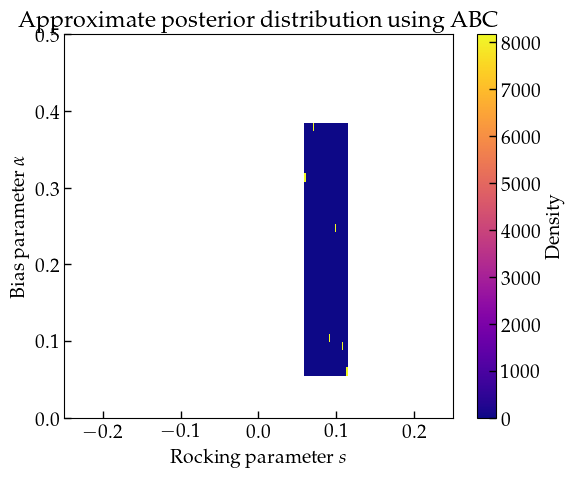

In [26]:

plt.figure(figsize=(6, 5))
plt.hist2d(results['s'], results['alpha'], bins=30, density=True, cmap='plasma')
plt.colorbar(label='Density')
plt.xlabel(r'Rocking parameter $s$')
plt.ylabel(r'Bias parameter $\alpha$')
plt.title('Approximate posterior distribution using ABC')
plt.xlim(-0.25, 0.25)
plt.ylim(0, 0.5)

plt.tight_layout()
plt.show()


## **Training Neural Network**

In [27]:

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X = training_data.reshape(-1, n_cols)
Y = np.array([A.ravel(), S.ravel()]).T
X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y_scaled, train_size=0.75, random_state=19)
mlp = MLPRegressor(hidden_layer_sizes=(50, 50), activation='tanh', solver='adam', max_iter=5000, random_state=19)

mlp.fit(X_train, Y_train)


MLPRegressor(activation='tanh', hidden_layer_sizes=(50, 50), max_iter=5000,
             random_state=19)

In [33]:

# Evaluate the model
Y_pred = mlp.predict(X_test)
Y_pred = scaler_Y.inverse_transform(Y_pred)
Y_test = scaler_Y.inverse_transform(Y_test)
mse = np.mean((Y_test - Y_pred) ** 2, axis=0)
print(f'Mean Squared Error on test set: alpha: {mse[0]:.6f}, s: {mse[1]:.6f}')


Mean Squared Error on test set: alpha: 0.015496, s: 0.017665


In [29]:

results = ABC(y_obs, its, h='cal', cal_its=100, NN=mlp)


Kernel size calibration:   0%|          | 0/100 [00:00<?, ?it/s]

Kernel size calibration: 100%|██████████| 100/100 [01:11<00:00,  1.40it/s]


Chosen kernel size:  0.12940000000000218


Running ABC iterations: 100%|██████████| 100/100 [01:12<00:00,  1.39it/s]


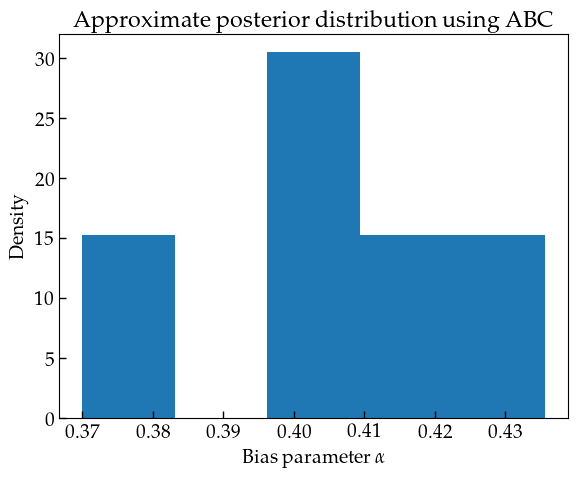

In [32]:

plt.figure(figsize=(6, 5))
plt.hist(results['alpha'], bins=5, density=True)
plt.xlabel(r'Bias parameter $\alpha$')
plt.ylabel(r'Density')
plt.title('Approximate posterior distribution using ABC')

plt.tight_layout()
plt.show()


## **Chain of Transformers**

---